In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
import scipy.stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.arima_process import arma2ma
from statsmodels.tsa.x13 import x13_arima_analysis

In [6]:
df = pd.read_csv('inflation_data.csv')

# -----------------------------------------------------------------------------
# Filter inflation data for the European Union (EU)
# -----------------------------------------------------------------------------
# geo    = 'EU'   → European Union aggregate
# unit   = 'I15'  → index (reference year = 2015)
# coicop = 'CP00' → all items (headline inflation)
# -----------------------------------------------------------------------------

# Keep only the relevant observations and variables
df = df.loc[
    (df["geo"] == "EU") &
    (df["unit"] == "I15") &
    (df["coicop"] == "CP00"),
    ["TIME_PERIOD", "OBS_VALUE"]
]

# Convert the time variable to a datetime index
df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"])
df = df.set_index("TIME_PERIOD").sort_index()

<Axes: title={'center': 'EU headline inflation index (2015 = 100)'}, xlabel='Time', ylabel='Index value'>

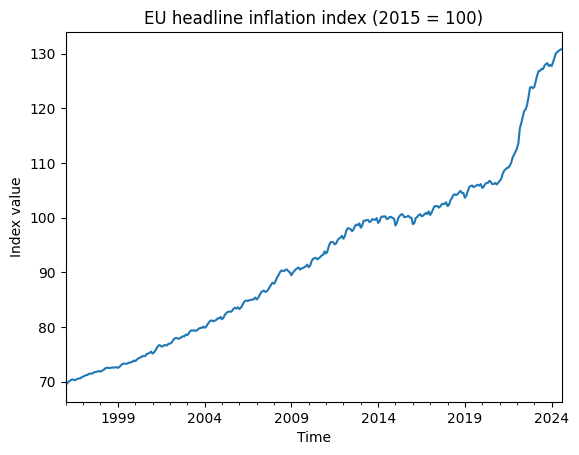

In [7]:
df["OBS_VALUE"].plot(
        title="EU headline inflation index (2015 = 100)",
        ylabel="Index value",
        xlabel="Time"
    )

In [8]:
# We use a monthly decomposition with period = 12.
# For an index series like HICP, a multiplicative decomposition is often sensible.
# Note: `seasonal_decompose` yields separate components (trend/seasonal/resid).
# If you want a seasonally-adjusted series, remove the seasonal component.

decomp = seasonal_decompose(
    df["OBS_VALUE"],
    model="multiplicative",   # seasonal effects scale with the level
    period=12,
    extrapolate_trend="freq"  # avoids NaNs at the sample ends for the trend
)

# Seasonally adjusted series (SA): observed / seasonal (multiplicative case)
df["OBS_VALUE_SA"] = df["OBS_VALUE"] / decomp.seasonal

# (Optional) Keep components for inspection
# df["trend"]    = decomp.trend
# df["seasonal"] = decomp.seasonal
# df["resid"]    = decomp.resid

<Axes: title={'center': 'EU headline inflation index (seasonally adjusted)'}, xlabel='Time', ylabel='Index value (2015 = 100)'>

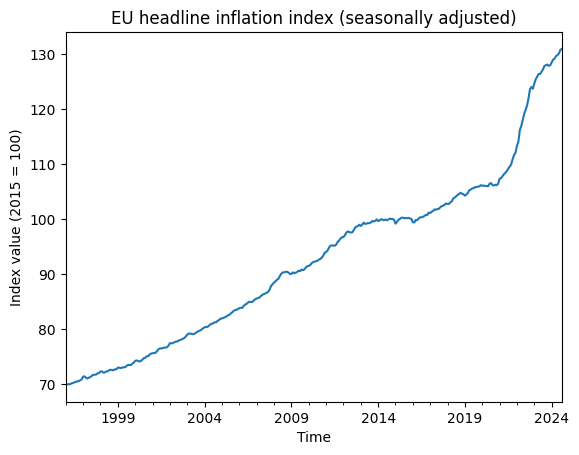

In [9]:
# -----------------------------------------------------------------------------
# plot the seasonally adjusted inflation index
# -----------------------------------------------------------------------------

df["OBS_VALUE_SA"].plot(
    title="EU headline inflation index (seasonally adjusted)",
    ylabel="Index value (2015 = 100)",
    xlabel="Time"
    )


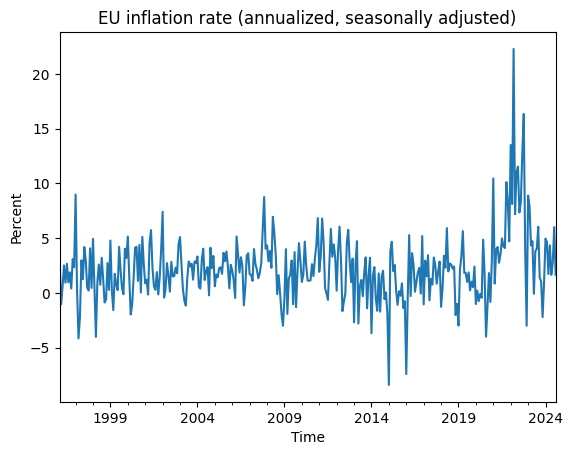

In [10]:
# -----------------------------------------------------------------------------
# Construct annualized inflation from the seasonally adjusted index
# -----------------------------------------------------------------------------
# Monthly inflation is computed as the percentage change in the index.
# We then annualize it by multiplying by 12 and express it in percent.
# -----------------------------------------------------------------------------

df["i"] = (
    df["OBS_VALUE_SA"]
    .pct_change()        # monthly growth rate
    .mul(12 * 100)       # annualization and percent scaling
)

# Note:
# This corresponds to an annualized month-on-month inflation rate.


# Drop any rows containing missing values (NaN) from the DataFrame
df.dropna(inplace=True)

# -----------------------------------------------------------------------------
# Optional: plot the annualized monthly inflation rate
# -----------------------------------------------------------------------------
if ploton:
    df["i"].plot(
        title="EU inflation rate (annualized, seasonally adjusted)",
        ylabel="Percent",
        xlabel="Time"
    )

In [11]:
# Augmented Dickey-Fuller test: is there a unit root?
# H0: there is a unit root
adfuller(df.i, regression='c')

(-3.777245649793565,
 0.0031488925771101786,
 15,
 327,
 {'1%': -3.45050711373316,
  '5%': -2.8704195794076743,
  '10%': -2.571500856923753},
 1537.3420646741856)

In [13]:
# -----------------------------------------------------------------------------
# Unit root diagnostic "à la Verbeek" (Chapter 8)
# -----------------------------------------------------------------------------
# We run the ADF test with a *fixed* number of lags and show how the conclusion
# can change when we add more lags.
#
# ADF null hypothesis (H0): unit root (non-stationarity).
# Verbeek’s point: for inflation, rejections are often marginal and become less
# likely as more lags are included → inflation is either I(1) or highly persistent I(0).
# -----------------------------------------------------------------------------

def adf_with_lags(x: pd.Series, lags: int, regression: str = "c") -> dict:
    # statsmodels versions differ: adfuller returns 5 or 6 elements depending on store/store_results
    out = adfuller(x.dropna(), regression=regression, autolag=None, maxlag=lags)

    stat = out[0]
    pval = out[1]
    usedlag = out[2]
    nobs = out[3]
    crit = out[4]

    return {
        "lags": usedlag,
        "adf_stat": stat,
        "p_value": pval,
        "crit_5": crit["5%"],
        "crit_10": crit["10%"],
    }

# Example lags (Verbeek reports 2 and 4, then “more lags”)
lags_list = [2, 4, 6, 8, 12]

rows = [adf_with_lags(df["i"], L) for L in lags_list]
adf_table = pd.DataFrame(rows)

print("ADF test with intercept (regression='c') — varying the number of lags")
print(adf_table.to_string(index=False, float_format=lambda z: f"{z: .3f}"))

# Interpretation (Verbeek-style):
# Compare adf_stat to critical values: reject H0 if adf_stat < crit value.
# If results are marginal and sensitive to lags, treat inflation as I(1) or very persistent I(0).

ADF test with intercept (regression='c') — varying the number of lags
 lags  adf_stat  p_value  crit_5  crit_10
    2    -6.778    0.000  -2.870   -2.571
    4    -4.686    0.000  -2.870   -2.571
    6    -3.327    0.014  -2.870   -2.571
    8    -3.408    0.011  -2.870   -2.571
   12    -3.293    0.015  -2.870   -2.571


In [ ]:
# -----------------------------------------------------------------------------
# KPSS test (complementary, Verbeek-style)
# -----------------------------------------------------------------------------
# KPSS null hypothesis (H0): stationarity.
# Verbeek’s point: for inflation, KPSS conclusions can depend on the bandwidth
# choice in the Newey–West correction → use as a diagnostic, not a verdict.
# -----------------------------------------------------------------------------

def kpss_with_bandwidth(x: pd.Series, regression: str = "c", nlags="auto") -> dict:
    stat, pval, usedlags, crit = kpss(
        x.dropna(), regression=regression, nlags=nlags
    )
    return {
        "nlags": usedlags,
        "kpss_stat": stat,
        "p_value": pval,
        "crit_5": crit["5%"],
        "crit_10": crit["10%"],
        "nlags_choice": nlags,
    }

# Show sensitivity to the bandwidth (number of lags in Newey–West)
# - "auto" uses an automatic rule
# - fixed integers force specific bandwidth choices
bandwidth_list = ["auto", 2, 4, 6, 8, 12]

rows = [kpss_with_bandwidth(df["i"], regression="c", nlags=bw) for bw in bandwidth_list]
kpss_table = pd.DataFrame(rows)

print("\nKPSS test with intercept (regression='c') — varying Newey–West bandwidth (nlags)")
print(kpss_table.to_string(index=False, float_format=lambda z: f"{z: .3f}"))

# Interpretation:
# Reject H0 (stationarity) if kpss_stat > critical value.
# If conclusions shift with nlags, emphasize "high persistence" rather than a binary I(0)/I(1) call.


KPSS test with intercept (regression='c') — varying Newey–West bandwidth (nlags)
 nlags  kpss_stat  p_value  crit_5  crit_10 nlags_choice
     9      0.388    0.083   0.463    0.347         auto
     2      0.845    0.010   0.463    0.347            2
     4      0.632    0.020   0.463    0.347            4
     6      0.501    0.041   0.463    0.347            6
     8      0.416    0.070   0.463    0.347            8
    12      0.324    0.100   0.463    0.347           12


/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_55426/3311033574.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, usedlags, crit = kpss(
/var/folders/gz/cs5w2f4s18l86vs9_v21ym1r0000gn/T/ipykernel_55426/3311033574.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, usedlags, crit = kpss(


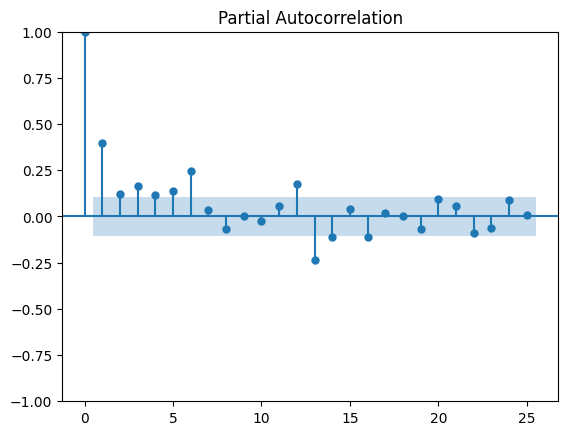

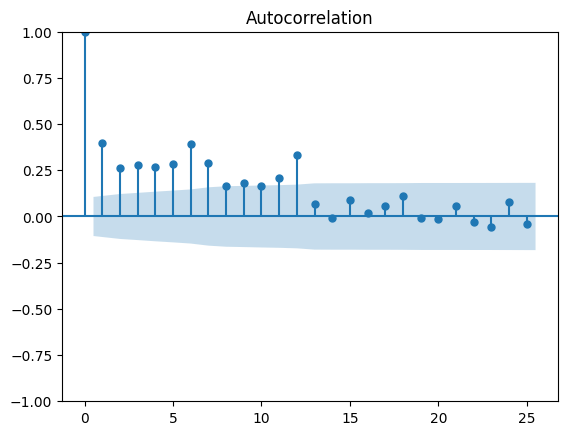

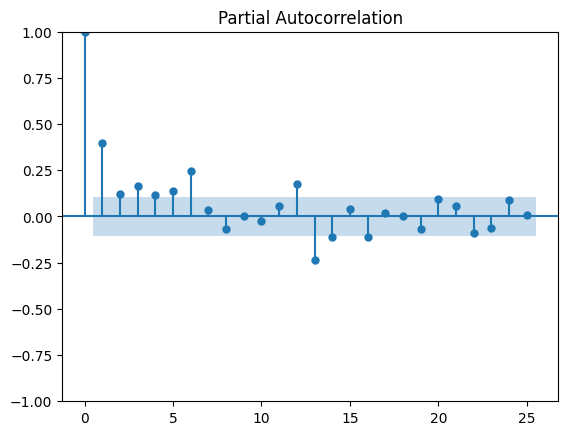

In [15]:
# ACF: high persistence confirmed
sm.graphics.tsa.plot_acf(
    df["i"],
    lags=25
)

# -----------------------------------------------------------------------------
# Partial Autocorrelation Function (PACF)
# -----------------------------------------------------------------------------
# We use the "ywm" method (Yule–Walker, modified):
#   • based on Yule–Walker equations for autoregressive processes,
#   • commonly used as a default in empirical macroeconomics.
# -----------------------------------------------------------------------------

sm.graphics.tsa.plot_pacf(
    df["i"],
    lags=25,
    method="ywm"
)

In [16]:
# -----------------------------------------------------------------------------
# Automatic AR order selection
# -----------------------------------------------------------------------------
# ar_select_order estimates AR(p) models for p = 0, …, maxlag
# and reports information criteria (AIC, BIC) to guide model choice.

mod = ar_select_order(df["i"], maxlag=12)

# Information criteria for each candidate model
mod.aic
mod.bic

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


{(1, 2, 3, 4, 5, 6): 1618.8265074425017,
 (1, 2, 3, 4, 5, 6, 7): 1624.1612801959639,
 (1, 2, 3, 4, 5, 6, 7, 8): 1628.337724554745,
 (1, 2, 3): 1633.1945388095953,
 (1, 2, 3, 4, 5): 1633.7332000886354,
 (1, 2, 3, 4, 5, 6, 7, 8, 9): 1634.1204350386388,
 (1, 2, 3, 4): 1634.4943802868006,
 (1,): 1636.3025056611998,
 (1, 2): 1637.2665423669719,
 (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12): 1639.6141804572644,
 (1, 2, 3, 4, 5, 6, 7, 8, 9, 10): 1639.7753813672239,
 (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11): 1644.742160679669,
 0: 1689.7687542512144}

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: title={'center': 'AR(6) residuals'}, xlabel='TIME_PERIOD'>

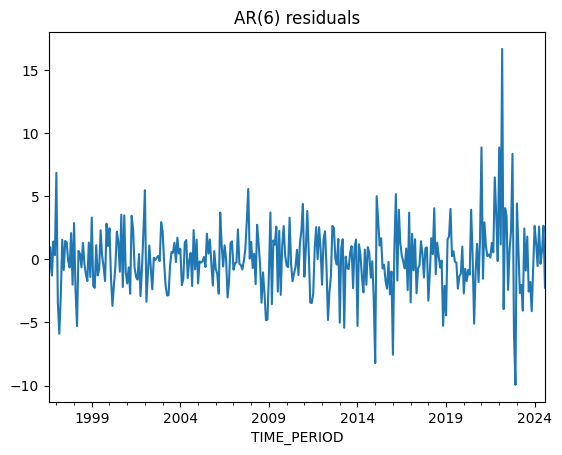

In [17]:
# -----------------------------------------------------------------------------
# Estimate the chosen model: AR(6)
# -----------------------------------------------------------------------------
# The AR(6) specification can be motivated by the PACF
# or by minimizing an information criterion.

ar6_model = AutoReg(df["i"], lags=6).fit()

# -----------------------------------------------------------------------------
# Optional: inspect residuals over time
# -----------------------------------------------------------------------------
# Residuals should look roughly uncorrelated and centered around zero.

ar6_model.resid.plot(title="AR(6) residuals")

In [18]:
# Ljung-Box test on the model residual: H0: The residuals are independently distributed 
acorr_ljungbox(ar6_model.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.121109,0.941718


In [19]:
# -----------------------------------------------------------------------------
# 1-step forecast standard error via AR -> MA(∞)
# -----------------------------------------------------------------------------
# For an AR model, the forecast error variance at horizon h is:
#   Var(e_{t+h|t}) = σ^2 * sum_{j=0}^{h-1} ψ_j^2
# where ψ_j are MA(∞) coefficients. For h=1, only ψ_0 = 1 matters.
# -----------------------------------------------------------------------------

sigma2 = ar6_model.resid.var(ddof=int(ar6_model.df_model) + 1)  # residual variance

# MA(∞) coefficients ψ_j (ψ_0 = 1)
ar_poly = [1] + list(-ar6_model.params[1:])  # AR polynomial: 1 - φ1 L - ... - φp L^p
psi = arma2ma(ar=ar_poly, ma=[1], lags=50)

h = 1
se_h = np.sqrt(sigma2 * np.sum(psi[:h] ** 2))

y_T_plus_1 = ar6_model.predict(start=len(df), end=len(df)).iloc[0]
forecast_interval_low  = y_T_plus_1 - 1.96 * se_h
forecast_interval_high = y_T_plus_1 + 1.96 * se_h

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [20]:
# -----------------------------------------------------------------------------
# Print block 
# -----------------------------------------------------------------------------
level = 95  # since we used 1.96
print(f"1-step ahead point forecast (t+1): {y_T_plus_1:.4f}")
print(
    f"1-step ahead {level}% PI: "
    f"[{forecast_interval_low:.4f}, {forecast_interval_high:.4f}]  (SE={se_h:.4f})"
)

1-step ahead point forecast (t+1): 2.1836
1-step ahead 95% PI: [-3.0372, 7.4045]  (SE=2.6637)


Selected AR order by AIC (Stock & Watson AR(AIC) idea): p = 12
                            AutoReg Model Results                             
Dep. Variable:                     di   No. Observations:                  342
Model:                    AutoReg(12)   Log Likelihood                -774.056
Method:               Conditional MLE   S.D. of innovations              2.526
Date:                Mon, 09 Feb 2026   AIC                           1576.112
Time:                        19:51:27   BIC                           1629.300
Sample:                    03-01-1997   HQIC                          1597.328
                         - 08-01-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.139      0.006      0.995      -0.272       0.273
di.L1         -0.6664      0.054    -12.433      0.000      -0.771  

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


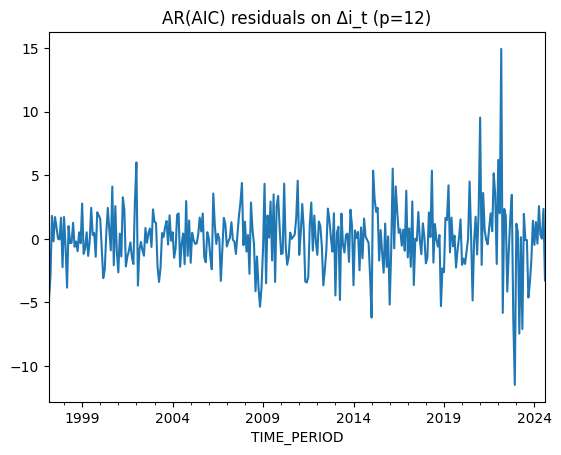

In [21]:
# -----------------------------------------------------------------------------
# Stock & Watson (2007) AR(AIC) benchmark — adapted to monthly EU inflation
# -----------------------------------------------------------------------------
# In Stock & Watson (2007), the baseline univariate forecast is an AR(AIC) model
# estimated on changes in inflation, allowing for a unit root in inflation levels.
#
# Their direct h-step specification is:
#   π^{(h)}_{t+h} - π_t = μ_h + α_h(B) Δπ_t + v^{(h)}_t
# with lag order chosen by AIC (recursively).
#
# Here we keep it simple and implement the key idea:
#   1) work with Δi_t (change in inflation rate)
#   2) pick p by AIC using ar_select_order
#   3) fit AR(p) to Δi_t
# -----------------------------------------------------------------------------

# 1) Construct Δi_t (Stock & Watson use Δπ_t in the AR(AIC) benchmark)
df["di"] = df["i"].diff()
df = df.dropna(subset=["di"])

# 2) Select AR order by AIC (as in AR(AIC))
sel = ar_select_order(df["di"], maxlag=12, ic="aic", trend="c")

p_aic = sel.ar_lags[-1] if sel.ar_lags is not None else 0  # selected lag order
print(f"Selected AR order by AIC (Stock & Watson AR(AIC) idea): p = {p_aic}")

# 3) Fit AR(p) on Δi_t
ar_aic_model = AutoReg(df["di"], lags=p_aic, trend="c").fit()
print(ar_aic_model.summary())

# Optional: residual plot
if ploton:
    ar_aic_model.resid.plot(title=f"AR(AIC) residuals on Δi_t (p={p_aic})")

In [ ]:
def adf_test(series, maxlag=None):
    result = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    return {
        "stat": result[0],
        "pvalue": result[1],
        "lags": result[2]
    }

def kpss_test(series, regression="c", nlags="auto"):
    stat, pvalue, lags, _ = kpss(series.dropna(), regression=regression, nlags=nlags)
    return {
        "stat": stat,
        "pvalue": pvalue,
        "lags": lags
    }

def integration_diagnosis(series, name):
    adf = adf_test(series)
    kpss = kpss_test(series)

    return pd.Series({
        "ADF stat": adf["stat"],
        "ADF p-value": adf["pvalue"],
        "KPSS stat": kpss["stat"],
        "KPSS p-value": kpss["pvalue"],
        "Conclusion": (
            "I(0)" if (adf["pvalue"] < 0.05 and kpss["pvalue"] > 0.05)
            else "I(1)" if (adf["pvalue"] > 0.05 and kpss["pvalue"] < 0.05)
            else "Inconclusive"
        )
    }, name=name)

# -----------------------------
# Sample splits
# -----------------------------

y = df["i"]  

y_full = y.copy()
y_pre_2019 = y[y.index < "2019-01-01"]
y_post_2019 = y[y.index >= "2019-01-01"]

# -----------------------------
# Run tests
# -----------------------------

results = pd.concat([
    integration_diagnosis(y_full, "Full sample"),
    integration_diagnosis(y_pre_2019, "Pre-2019"),
    integration_diagnosis(y_post_2019, "Post-2019")
], axis=1).T

results

,ADF stat,ADF p-value,KPSS stat,KPSS p-value,Conclusion
Full sample,-3.772189,0.003205,0.390883,0.081085,I(0)
Pre-2019,-3.334529,0.013404,0.352402,0.097672,I(0)
Post-2019,-1.740159,0.410549,0.40046,0.076957,Inconclusive


The Post-2019 data are not informative enough to clearly discriminate between stationarity and a unit root

In [ ]:
# Compute AR coefficients and cumulative response (MA(∞) and its cumulative sum)
p = int(ar6_model.k_ar) if hasattr(ar6_model, 'k_ar') else 6  # number of lags
ar_coefs = ar6_model.params.iloc[1:1+p].values  
sum_ar_coefs = ar_coefs.sum()

# Convert AR to MA(∞) and compute cumulative response
ar_poly = [1] + list(-ar_coefs)  # AR polynomial: 1 - φ1 L - ... - φp L^p
psi = arma2ma(ar=ar_poly, ma=[1], lags=200)  # increase lags for better long-run approx
cum_response = np.cumsum(psi)  # cumulative impulse response to a unit shock

# Summary / printing
print(f"AR coefficients (phi1..phip): {ar_coefs}")
print(f"Sum of AR coefficients (SARC): {sum_ar_coefs:.6f}")
print(f"Approx. long-run cumulative response (sum psi up to {len(psi)-1}): {cum_response[-1]:.6f}")

# Make results available for later cells
ar_response_summary = {
    'p': p,
    'ar_coefs': ar_coefs,
    'sum_ar_coefs': sum_ar_coefs,
    'psi': psi,
    'cum_response': cum_response,
    'long_run_approx': float(cum_response[-1])
}

AR coefficients (phi1..phip): [0.26348279 0.02243711 0.0878766  0.0653802  0.06151327 0.24660801]
Sum of AR coefficients (SARC): 0.747298
Approx. long-run cumulative response (sum psi up to 199): 3.957229


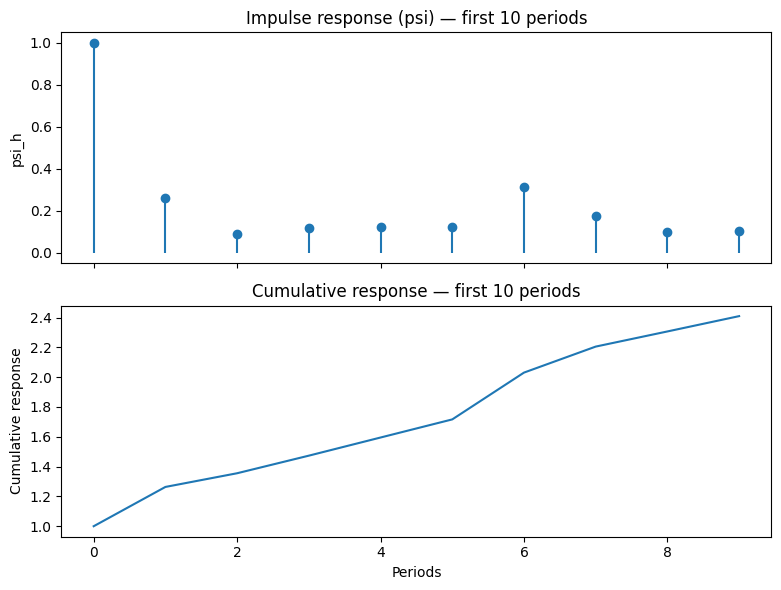

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

n_plot = 10  # number of periods to plot

# Impulse response (psi)
axes[0].stem(range(n_plot), irf[:n_plot], basefmt=' ')
axes[0].set_title('Impulse response (psi) — first 10 periods')
axes[0].set_ylabel('psi_h')

# Cumulative response (match same horizon)
cum_response_plot = np.cumsum(irf[:n_plot])
axes[1].plot(range(n_plot), cum_response_plot)
axes[1].set_title('Cumulative response — first 10 periods')
axes[1].set_ylabel('Cumulative response')
axes[1].set_xlabel('Periods')

plt.tight_layout()
